# 1. Предобработка данных для анализа интернет-магазина

## Цели:
- Загрузка сырых данных
- Очистка и преобразование данных
- Объединение datasets
- Сохранение готовых данных для анализа

In [1]:
import sys
import os
from pathlib import Path

# Получаем абсолютный путь к корню проекта (где находятся папки src, config, notebooks, data)
project_root = Path.cwd().parent

# Добавляем корень проекта в путь для импорта
sys.path.insert(0, str(project_root))

print(f"Корневая папка проекта: {project_root}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем модули
from src.data_loader import DataLoader
from src.preprocessing import DataPreprocessor
from config.constants import PROJECT_ROOT, DATA_RAW, DATA_PROCESSED

print(f"Папка с сырыми данными: {DATA_RAW}")
print(f"Папка с обработанными данными: {DATA_PROCESSED}")

Корневая папка проекта: c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz
Папка с сырыми данными: c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz\data\raw
Папка с обработанными данными: c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz\data\processed


In [2]:
loader = DataLoader()
preprocessor = DataPreprocessor()

In [3]:
print("ЗАГРУЗКА ДАННЫХ...")
products, sales = loader.load_all_data()

ЗАГРУЗКА ДАННЫХ...
ЗАГРУЗКА ДАННЫХ...
Загрузка товаров из: c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz\data\raw\anonymous_seller_product.csv
✓ Успешно: anonymous_seller_product.csv (sep=';', encoding=utf-8, shape=(959, 22))
Загружено 959 записей о товарах
Колонки товаров: ['Артикул', 'Ozon Product ID', 'SKU', 'Barcode', 'Контент-рейтинг', 'Бренд', 'Метки', 'Отзывы', 'Рейтинг', 'Категория', 'Тип', 'Объем товара, л', 'Объемный вес, кг', 'Доступно к продаже по схеме FBO, шт.', 'Зарезервировано, шт', 'Доступно к продаже по схеме FBS, шт.', 'Доступно к продаже по схеме realFBS, шт.', 'Зарезервировано на моих складах, шт', 'Текущая цена с учетом скидки, ₽', 'Цена до скидки (перечеркнутая цена), ₽', 'Цена Premium, ₽', 'Размер НДС, %']
Загрузка продаж из: c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz\data\raw\anonymous_oz_sales_data.csv
✓ Успешно: anonymous_oz_sales_data.csv (sep=';', encoding=utf-8, shape=(2354, 18))
Загружено 2354 записей о продажах
Колонки продаж: ['Номер отправления', 

### Просмотр структуры данных


In [4]:
print("ПРОСМОТР ДАННЫХ О ТОВАРАХ:")
products.head()
print("\nИнформация о товарах:")
products.info()

ПРОСМОТР ДАННЫХ О ТОВАРАХ:

Информация о товарах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 22 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Артикул                                   959 non-null    object 
 1   Ozon Product ID                           959 non-null    int64  
 2   SKU                                       959 non-null    int64  
 3   Barcode                                   959 non-null    object 
 4   Контент-рейтинг                           959 non-null    object 
 5   Бренд                                     952 non-null    object 
 6   Метки                                     0 non-null      float64
 7   Отзывы                                    959 non-null    int64  
 8   Рейтинг                                   959 non-null    object 
 9   Категория                                 959 non-null    o

In [5]:
print("ПРОСМОТР ДАННЫХ О ПРОДАЖАХ:")
sales.head()
print("\nИнформация о продажах:")
sales.info()

ПРОСМОТР ДАННЫХ О ПРОДАЖАХ:

Информация о продажах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Номер отправления                 2354 non-null   object
 1   Статус отправления                2354 non-null   object
 2   Ozon ID                           2354 non-null   int64 
 3   Артикул товара                    2354 non-null   object
 4   Итоговая стоимость                2354 non-null   int64 
 5   Количество товаров в отправлении  2354 non-null   int64 
 6   Скидка %                          2354 non-null   int64 
 7   Акции                             2354 non-null   object
 8   Регион доставки                   2354 non-null   object
 9   Способ доставки                   2354 non-null   object
 10  Сумма отправления                 2354 non-null   int64 
 11  Скидка, руб.                  

In [6]:
# Предобработка данных
print("ПРЕДОБРАБОТКА ДАННЫХ...")
merged_data = preprocessor.run_full_preprocessing(products, sales)

ПРЕДОБРАБОТКА ДАННЫХ...
Запуск полного пайплайна предобработки...
Начата предобработка товаров...
Преобразовано Рейтинг -> rating
Преобразовано Объем товара, л -> volume_l
Преобразовано Объемный вес, кг -> volume_weight_kg
Преобразовано Размер НДС, % -> vat_percent
Товары после предобработки: 959 записей
Начата предобработка продаж...
Преобразовано Скидка, руб. -> discount_rub
Преобразовано Вознаграждение, руб. -> commission_rub
Преобразовано К выплате -> payout
Расчет бизнес-метрик...
Бизнес-метрики рассчитаны
Продажи после предобработки: 2354 записей
Объединение datasets...
Объединенный dataset: 2366 записей
✓ Предобработка завершена. Размер данных: (2366, 64)


In [9]:
# Проверка результатов
print("РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ:")
print(f"Размер объединенного dataset: {merged_data.shape}")
print("\nКолонки в dataset:")
merged_data.columns.tolist()
merged_data.info()

РЕЗУЛЬТАТЫ ПРЕДОБРАБОТКИ:
Размер объединенного dataset: (2366, 64)

Колонки в dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2366 entries, 0 to 2365
Data columns (total 64 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Номер отправления                         2366 non-null   object        
 1   Статус отправления                        2366 non-null   object        
 2   Ozon ID                                   2366 non-null   int64         
 3   Артикул товара                            2366 non-null   object        
 4   Итоговая стоимость                        2366 non-null   int64         
 5   Количество товаров в отправлении          2366 non-null   int64         
 6   Скидка %                                  2366 non-null   int64         
 7   Акции                                     2366 non-null   object        
 8   Регион доставки      

In [10]:
# Статистика по числовым колонкам
print("СТАТИСТИКА ПО ЧИСЛОВЫМ ПОЛЯМ:")
numeric_cols = merged_data.select_dtypes(include=[np.number]).columns
print(merged_data[numeric_cols].describe())

СТАТИСТИКА ПО ЧИСЛОВЫМ ПОЛЯМ:
            Ozon ID  Итоговая стоимость  Количество товаров в отправлении  \
count  2.366000e+03         2366.000000                       2366.000000   
mean   5.525051e+07         4949.587067                          2.510989   
std    2.561029e+07         2686.583298                          1.117460   
min    1.005214e+07          150.000000                          1.000000   
25%    3.333686e+07         2933.000000                          2.000000   
50%    5.437556e+07         4990.000000                          3.000000   
75%    7.810856e+07         6580.000000                          4.000000   
max    9.997364e+07        11990.000000                          4.000000   

          Скидка %  Сумма отправления  Вознаграждение %  Стоимость доставки  \
count  2366.000000        2366.000000       2366.000000         2366.000000   
mean      9.997887       12395.564243         14.478867          302.101860   
std       7.049358        9173.979963  

In [11]:
# Проверка пропусков после обработки
print("ПРОПУСКИ ПОСЛЕ ОБРАБОТКИ:")
missing_data = merged_data.isnull().sum()
print(missing_data[missing_data > 0])

ПРОПУСКИ ПОСЛЕ ОБРАБОТКИ:
Метки              2366
Цена Premium, ₽    2366
dtype: int64


In [13]:
# Сохранение обработанных данных
preprocessor.save_processed_data(merged_data)

Данные сохранены в c:\Users\majkl\WorkSpace\Analisys_seller_mp_oz\data\processed\merged_data.csv


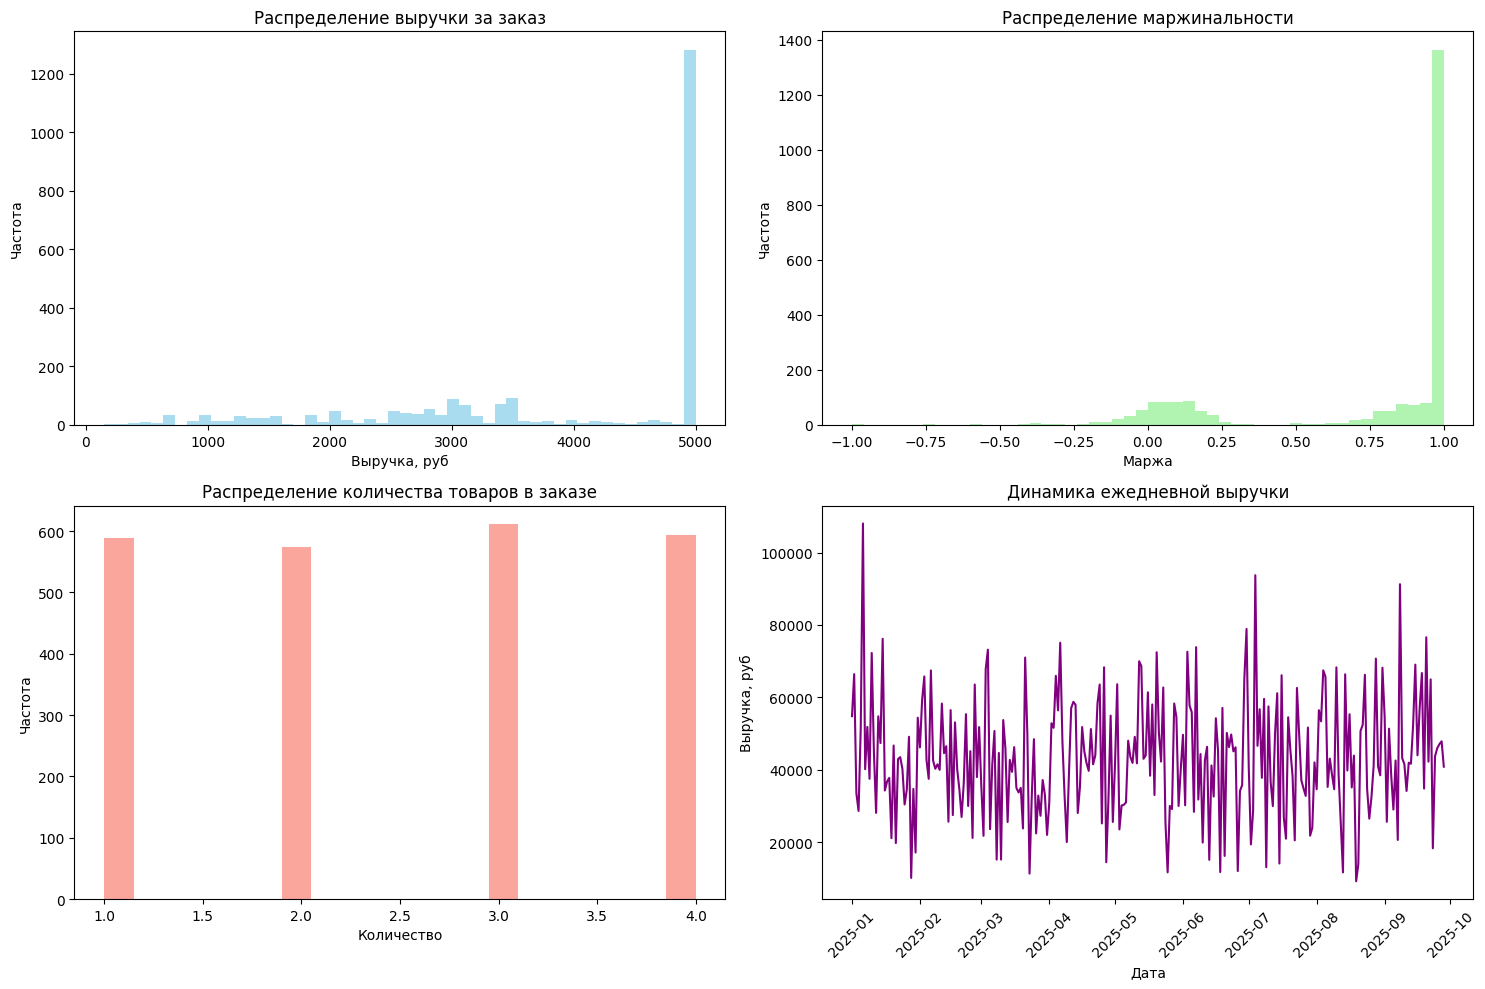

In [15]:
# Визуализация распределения ключевых метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Распределение выручки
axes[0,0].hist(merged_data['revenue'].clip(0, 5000), bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('Распределение выручки за заказ')
axes[0,0].set_xlabel('Выручка, руб')
axes[0,0].set_ylabel('Частота')

# Распределение маржи
axes[0,1].hist(merged_data['margin'].clip(-1, 1), bins=50, alpha=0.7, color='lightgreen')
axes[0,1].set_title('Распределение маржинальности')
axes[0,1].set_xlabel('Маржа')
axes[0,1].set_ylabel('Частота')

# Распределение количества товаров
axes[1,0].hist(merged_data['quantity'], bins=20, alpha=0.7, color='salmon')
axes[1,0].set_title('Распределение количества товаров в заказе')
axes[1,0].set_xlabel('Количество')
axes[1,0].set_ylabel('Частота')

# Временной ряд продаж
daily_sales = merged_data.groupby(merged_data['date'].dt.date)['revenue'].sum()
axes[1,1].plot(daily_sales.index, daily_sales.values, color='purple')
axes[1,1].set_title('Динамика ежедневной выручки')
axes[1,1].set_xlabel('Дата')
axes[1,1].set_ylabel('Выручка, руб')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/01_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("ПРЕДОБРАБОТКА ЗАВЕРШЕНА!")
print(f"Готовый dataset содержит:")
print(f"- {merged_data.shape[0]} записей о продажах")
print(f"- {merged_data['sku'].nunique()} уникальных товаров")
print(f"- {merged_data['customer_id'].nunique()} уникальных клиентов")
print(f"- Период с {merged_data['date'].min()} по {merged_data['date'].max()}")

ПРЕДОБРАБОТКА ЗАВЕРШЕНА!
Готовый dataset содержит:
- 2366 записей о продажах
- 859 уникальных товаров
- 861 уникальных клиентов
- Период с 2025-01-01 00:00:00 по 2025-09-28 00:00:00
